In [34]:
import os, sys
import re
import argparse
import pickle
import tarfile
import tempfile
from glob import glob
from functools import reduce

import numpy as np
import pandas as pd
import lightkurve as lk
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from tqdm import tqdm
from astrocut import CutoutFactory
from astropy.stats import sigma_clip

from tess_asteroid_ml import *
from tess_asteroid_ml.make_TESS_asteroid_db import *
from tess_asteroid_ml.utils import in_cutout
from tess_asteroid_ml.make_TESScut_asteroids import *

In [35]:
sector = 5
camera = 2
ccd = 3
sampling = "dense"
fit_bkg = False
limiting_mag = 22
cutout_size = 64
verbose = True
plot = False
download =False
download_only = False

In [175]:
provider = "mast"

# get FFI image
ffi_file = get_FFI_name(
    sector=sector, camera=camera, ccd=ccd, provider=provider, correct=False
)
if verbose:
    print(f"Working on FFI sector {sector} camera {camera} ccd {ccd}")
    print(f"FFI file is {ffi_file[0]}")

# get FFI data to build ra/dec coordinates for later query
ffi_header, f2d, col_2d, row_2d, ra_2d, dec_2d = get_data_from_files(
    ffi_file, provider=provider
)
ffi_header = ffi_header[0]
f2d = f2d[0]
col_2d = col_2d
row_2d = row_2d
ra_2d = ra_2d[0]
dec_2d = dec_2d[0]

obs_time = Time([ffi_header["DATE-OBS"], ffi_header["DATE-END"]], format="isot")

# get asteroid catalog
jpl_df = get_asteroid_table(
    SkyCoord(ra_2d.min() * u.deg, dec_2d.min() * u.deg, frame="icrs"),
    SkyCoord(ra_2d.max() * u.deg, dec_2d.max() * u.deg, frame="icrs"),
    sector=sector,
    camera=camera,
    ccd=0,
    date_obs=obs_time.mean().jd,
)
if limiting_mag <= 30:
    asteroid_df = jpl_df.query(f"V_mag <= {limiting_mag}")
if verbose:
    print(f"Asteroid table has {len(asteroid_df)} items with V < {limiting_mag}")

# get asteroid tracks in low res
sb_ephems_hires = read_asteroid_db(
    asteroid_df, low_res=False, small=True, sector=sector, camera=camera, ccd=ccd
)
if verbose:
    print(f"Asteroid track DB has {len(sb_ephems_hires)} available")

# get cutout centers given size and overlap
xcen, ycen = get_cutout_centers(sampling="tiled", overlap=4, size=cutout_size)
# create a dict with cutout centers in radec
cut_dict = {}
for i in ycen[:, 0]:
    if row_2d[i,j] > 1500 or row_2d[i,j] < 1300:
        continue
    for j in xcen[0, :]:
        cut_dict[f"c{col_2d[i, j]:04}_r{row_2d[i,j]:04}"] = SkyCoord(
            ra_2d[i, j] * u.deg, dec_2d[i, j] * u.deg, frame="icrs"
        )
    # break

tpf_names_list = get_ffi_cutouts(
    coords=cut_dict,
    sampling=sampling,
    download=download,
    sector=sector,
    cam_ccd=f"{camera}-{ccd}",
    cutout_size=cutout_size,
)
tot_cutouts = len([x for xs in tpf_names_list for x in xs])
if verbose:
    print(f"Total cutouts in disk {tot_cutouts}")
if sampling == "dense" and tot_cutouts != len(cut_dict):
    raise FileNotFoundError(f"Found only {tot_cutouts} instead of {len(cut_dict)}")
if download_only:
    sys.exit()

if np.max([len(x) for x in tpf_names_list]) == 0:
    print(
        "WARNING: No cutout TPFs available in disk. Please run again with "
        "`--download` flag to get the data"
    )

Working on FFI sector 5 camera 2 ccd 3
FFI file is https://archive.stsci.edu/missions/tess/ffi/s0005/2018/333/2-3/tess2018333072938-s0005-2-3-0125-s_ffic.fits


Set MJD-END to 58451.337719 from DATE-END'. [astropy.wcs.wcs]


Loading from CSV file: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/jpl/jpl_small_bodies_tess_s0005-2-0_catalog.csv
JPL SBI found 2130 asteroids with V < 30 in s0005-2-0
Asteroid table has 1463 items with V < 22


Asteroid track DB has 1234 available
Total cutouts in disk 102


In [169]:
comets_tracks = read_asteroid_db(
    jpl_df.query("kind == 'c'"), low_res=False, small=False, sector=sector, camera=camera, ccd=ccd
)

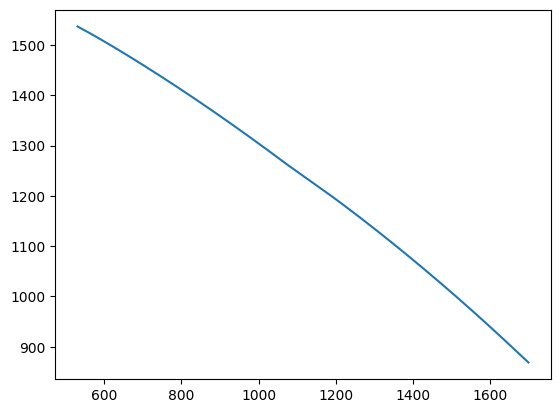

In [172]:
plt.plot(comets_tracks[1628].column, comets_tracks[1628].row,)

In [176]:
tpf_names_list

[['/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c1398_r1354_64x64pix.fits',
  '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c0618_r1354_64x64pix.fits',
  '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c0978_r1354_64x64pix.fits',
  '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c1458_r1354_64x64pix.fits',
  '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c0258_r1354_64x64pix.fits',
  '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c1818_r1354_64x64pix.fits',
  '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c1338_r1354_64x64pix.fits',
  '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0005/TESScut_s0005-2-3_c1938_r1354_64x64pix.fits',


In [178]:
# iterate over cutouts row in the grid
for nn, tpf_names in enumerate(tpf_names_list):
    if len(tpf_names) == 0:
        continue
    nrow = np.unique(
        [int(re.findall(r"\_c(\d+)\_r(\d+)\_", string=x)[0][1]) for x in tpf_names]
    )[0]
    if verbose:
        print(
            f"Working with FFI row {nn + 1}/{len(tpf_names_list)} "
            f"and {len(tpf_names)} cuts..."
        )
    # iterate cutouts in a single row
    F, X, Y, L, NAMES, CAD, COMET = [], [], [], [], [], [], []
    # sb_ephems_hires = {}
    
    for q, ff in tqdm(
        enumerate(tpf_names),
        total=len(tpf_names),
        desc=f"TESS cut files row {nrow + 1}",
    ):
        fficut_aster = AsteroidTESScut(lk.read(ff, quality_bitmask=None))
        fficut_aster.ffi_exp_time = (
            (ffi_header["TSTOP"] - ffi_header["TSTART"]) * 24 * 3600
        )
        if fit_bkg:
            fficut_aster.fit_background(polyorder=3, positive_flux=True)

        comet_aux = np.zeros(fficut_aster.ntimes).astype(bool)

        for k, val in sb_ephems_hires.items():
            if len(val) <= 1:
                continue
            
            # if k not in sb_ephems_hires.keys():
            #     sb_ephems_hires.update(
            #         read_asteroid_db(
            #             asteroid_df.loc[[k]],
            #             low_res=False,
            #             sector=sector,
            #             camera=camera,
            #             ccd=ccd,
            #             quiet=True,
            #         )
            #     )
            # check if asteroid track passes over the TESScut
            is_in = in_cutout(
                fficut_aster.column,
                fficut_aster.row,
                sb_ephems_hires[k].column.values,
                sb_ephems_hires[k].row.values,
            )
            # print(k, val.shape, sb_ephems_hires[k].shape, is_in)
            if is_in:
                source_rad = 3.2e2 / (sb_ephems_hires[k].vmag.mean()) ** 1.8
                fficut_aster.get_asteroid_mask(
                    sb_ephems_hires[k],
                    name=asteroid_df.loc[k, ["Object name", "V_mag"]],
                    mask_type="circular",
                    mask_radius=source_rad,
                    mask_num_type="dec",
                )
                if asteroid_df.loc[k, "kind"] == "c":
                    ast_idx = list(fficut_aster.asteroid_names.keys())[-1]
                    comet_aux |= np.isin(np.arange(fficut_aster.ntimes), fficut_aster.asteroid_time_idx[ast_idx])

        F.append(fficut_aster.flux_2d)
        X.append(fficut_aster.column_2d[0, 0])
        Y.append(fficut_aster.row_2d[0, 0])
        L.append(fficut_aster.asteroid_mask_2d)
        CAD.append(fficut_aster.cadenceno[fficut_aster.quality_mask])
        COMET.append(comet_aux)
        if hasattr(fficut_aster, "asteroid_names"):
            NAMES.append(
                pd.DataFrame.from_dict(fficut_aster.asteroid_names, orient="index")
            )
        else:
            NAMES.append(pd.DataFrame([]))

    keep_cad = reduce(np.intersect1d, CAD)
    keep_mask = [np.isin(C, keep_cad) for C in CAD]

    # make 4d arrays (n_cutout, n_time, n_col, n_row)
    F = np.array([F[k][keep_mask[k]] for k in range(len(F))])
    L = np.array([L[k][keep_mask[k]] for k in range(len(L))])
    COMET = np.array([COMET[k][keep_mask[k]] for k in range(len(COMET))])
    X, Y = np.array(X), np.array(Y)

    # make others arrays, time, CBV, quat and angles
    keep_mask = np.isin(fficut_aster.cadenceno[fficut_aster.quality_mask], keep_cad)
    TIME = fficut_aster.time[keep_mask]
    CAD = keep_cad

    dts = np.diff(TIME)
    breaks = np.where(dts >= 0.2)[0] + 1

    if verbose:
        print(f"Data breaks in cadences: {breaks}")

    if False:
        plt.plot(TIME)
        for bk in breaks:
            plt.axvline(bk, c="r")
        plt.show()

    if len(breaks) > 0:
        F = np.array_split(F, breaks, axis=1)
        L = np.array_split(L, breaks, axis=1)
        TIME = np.array_split(TIME, breaks, axis=0)
        CAD = np.array_split(CAD, breaks, axis=0)
        COMET = np.array_split(COMET, breaks, axis=1)
    else:
        F = [F]
        L = [L]
        TIME = [fficut_aster.time]
        CAD = [CAD]
        COMET = [COMET]

    break

Working with FFI row 1/3 and 34 cuts...


TESS cut files row 1355: 100%|███████████████████████████████████████████████████████| 34/34 [01:57<00:00,  3.46s/it]


Data breaks in cadences: [577]


In [82]:
cube_row2d = []
cube_col2d = []

for r, c in zip(Y, X):
    _row2d, _col2d = np.mgrid[r : r + 64, c : c + 64]
    cube_row2d.append(_row2d)
    cube_col2d.append(_col2d)

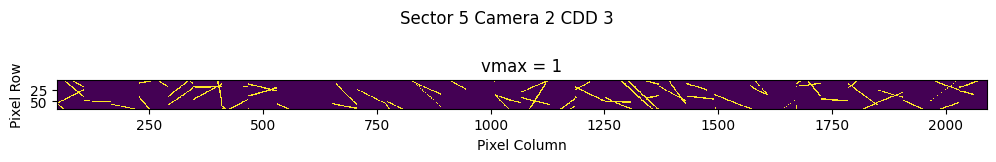

In [185]:
fig, ax = plt.subplots(1, 1, figsize=(12,2))
fig.suptitle(f"Sector {sector} Camera {camera} CDD {ccd}", y=0.92)

for k in range(len(L[0])):
    ax.set_title(f"vmax = {1}")
    ax.pcolormesh(
        cube_col2d[k],
        cube_row2d[k],
        L[0][k].sum(axis=0),
        cmap="viridis",
        vmin=0,
        vmax=1,
    )

ax.set_aspect('equal', 'box')
ax.invert_yaxis()
ax.set_xlabel("Pixel Column")
ax.set_ylabel("Pixel Row")


# plt.save(
#     f"home/jimartin/tess/tess-asteroid-ml/data/figures/asteroid_mask_s{sector:04}-{camera}-{ccd}.png",
#     bbox_inches="tight",
# )
plt.show()


In [201]:
lcf = lk.search_lightcurve('TIC 99180739', author='SPOC', sector=10).download()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

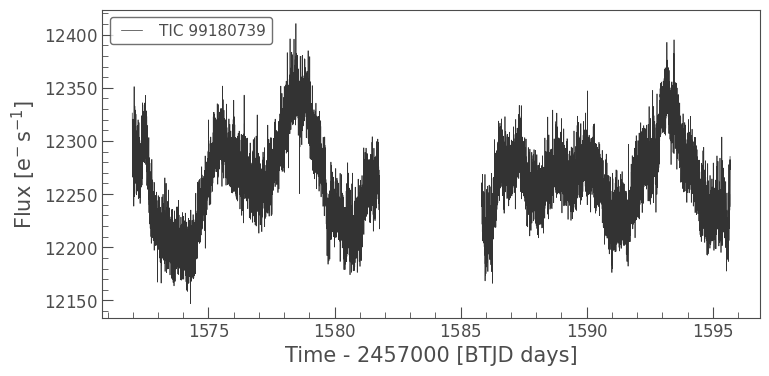

In [202]:
lcf.plot()

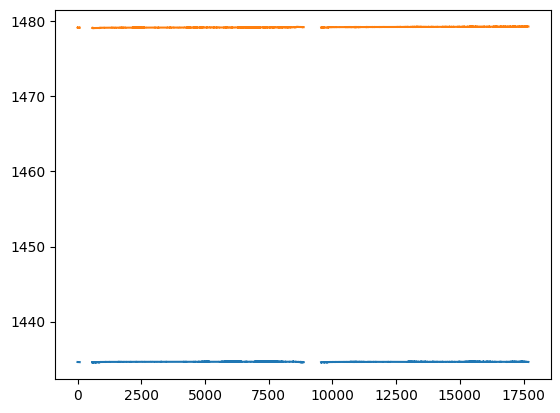

In [207]:
plt.plot(lcf.mom_centr1.value)
plt.plot(lcf.mom_centr2.value)

In [203]:
lcf.__dir__()

['_required_columns_relax',
 '_required_columns',
 '_masked',
 '_column_class',
 'columns',
 'formatter',
 '_copy_indices',
 '_init_indices',
 'primary_key',
 '_meta',
 '_first_colname',
 '_required_columns_enabled',
 'pprint_exclude_names',
 'pprint_include_names',
 '_new_attributes_relax',
 '__module__',
 '__doc__',
 '_deprecated_keywords',
 '_default_time_format',
 'read',
 'to_fits',
 '_deprecated_column_keywords',
 '_default_time_scale',
 '__array_priority__',
 '__init__',
 '__getattr__',
 '__setattr__',
 '_repr_simple_',
 '_base_repr_',
 'time',
 'flux',
 'flux_err',
 'select_flux',
 'time_format',
 'time_scale',
 'astropy_time',
 'flux_unit',
 'flux_quantity',
 'hdu',
 'SAP_FLUX',
 'PDCSAP_FLUX',
 '__add__',
 '__radd__',
 '__sub__',
 '__rsub__',
 '__mul__',
 '__rmul__',
 '__truediv__',
 '__rtruediv__',
 '__div__',
 '__rdiv__',
 'show_properties',
 'append',
 'flatten',
 'fold',
 'normalize',
 'remove_nans',
 'fill_gaps',
 'remove_outliers',
 'bin',
 'estimate_cdpp',
 'query_sola